In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#Definir las funciones de activación y entrenamiento
def step_function(x):
  return np.where(x>= 0,1,0)

#Función para hacer predicciones
def perceptron_predict(x, weights1, weights2):
  y1 = step_function(np.dot(x, weights1[1:]) + weights1[0])
  y2 = step_function(np.dot(x, weights2[1:]) + weights2[0])

  return np.array([y1, y2])

In [17]:
#Algoritmo de entrenamiento

def train(X, y1, y2,learning_rate = 0.1, epochs=10):
  weights1 = np.random.rand(X.shape[1] + 1)
  weights2 = np.random.rand(X.shape[1] + 1)
  error1 = []
  error2 = []
  for _ in range(epochs):
    total_error1 = 0
    total_error2 = 0
    for xi, target1, target2 in zip(X, y1, y2):
        output = perceptron_predict(xi, weights1, weights2)
        err1 = target1 - output[0]
        err2 = target2 - output[1]

        total_error1 += abs(err1)
        total_error2 += abs(err2)

        update1 = learning_rate * err1
        weights1[1:] += update1 * xi
        weights1[0] += update1

        update2 = learning_rate * err2
        weights2[1:] += update2 * xi
        weights2[0] += update2
    error1.append(total_error1)
    error2.append(total_error2)
  return weights1, weights2, error1, error2

Pesos entrenados para la neurona 1: [-0.83566893  0.39249162  0.23767699  0.26324005]
Pesos entrenados para la neurona 2: [-0.09400737  0.7064883   0.13383048  0.19474001]


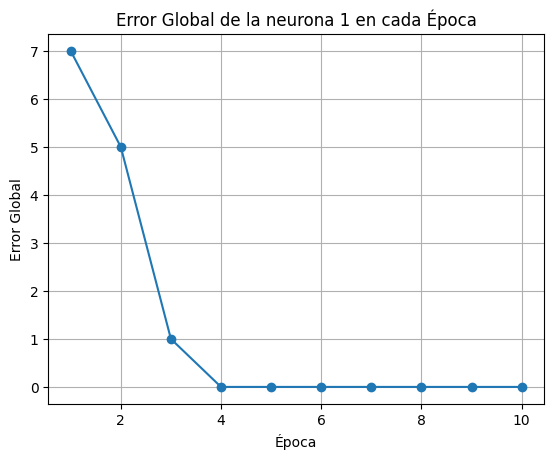

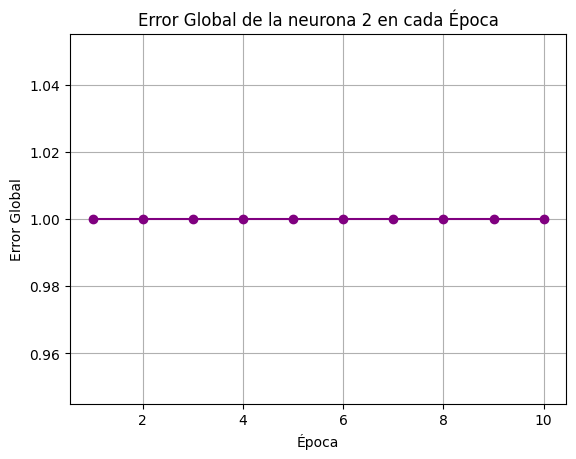

In [18]:
# Preparar los datos de entrada y salida
# Datos de entrada para la compuerta AND
X = np.array([[0, 0, 0],
              [0, 0, 1],
              [0, 1, 0],
              [0, 1, 1],
              [1, 0, 0],
              [1, 0, 1],
              [1, 1, 0],
              [1, 1, 1]])

# Salidas esperadas para la compuerta AND
y = np.array([0, 0, 0, 0, 0, 0, 0, 1])
# Salidas esperadas para la compuerta OR
y1 = np.array([0, 1, 1, 1, 1, 1, 1, 1])

# Entrenar el perceptrón
weights1, weights2, errors, errors2 = train(X, y, y1, learning_rate=0.1, epochs=10)
print("Pesos entrenados para la neurona 1:", weights1)
print("Pesos entrenados para la neurona 2:", weights2)

# Graficar el error global en cada época para la neurona1
plt.figure(1)
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global de la neurona 1 en cada Época')
plt.grid(True)
plt.show()

# Graficar el error global en cada época para la neurona2
plt.figure(2)
plt.plot(range(1, len(errors) + 1), errors2, marker='o', color = 'purple')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global de la neurona 2 en cada Época')
plt.grid(True)
plt.show()




In [19]:
print('COMPUERTA AND')
for xi in X:
    prediction = perceptron_predict(xi, weights1, weights2)
    print(f"Entrada: {xi}, Salida predicha: {prediction[0]}")

print('\nCOMPUERTA OR')
for xi in X:
  prediction = perceptron_predict(xi, weights1, weights2)
  print(f"Entrada: {xi}, Salida predicha: {prediction[1]}")


COMPUERTA AND
Entrada: [0 0 0], Salida predicha: 0
Entrada: [0 0 1], Salida predicha: 0
Entrada: [0 1 0], Salida predicha: 0
Entrada: [0 1 1], Salida predicha: 0
Entrada: [1 0 0], Salida predicha: 0
Entrada: [1 0 1], Salida predicha: 0
Entrada: [1 1 0], Salida predicha: 0
Entrada: [1 1 1], Salida predicha: 1

COMPUERTA OR
Entrada: [0 0 0], Salida predicha: 0
Entrada: [0 0 1], Salida predicha: 1
Entrada: [0 1 0], Salida predicha: 1
Entrada: [0 1 1], Salida predicha: 1
Entrada: [1 0 0], Salida predicha: 1
Entrada: [1 0 1], Salida predicha: 1
Entrada: [1 1 0], Salida predicha: 1
Entrada: [1 1 1], Salida predicha: 1


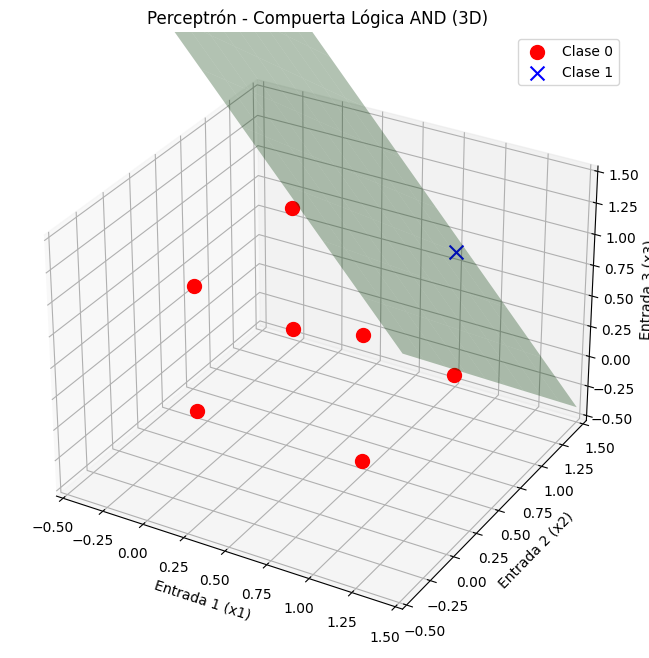

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos de datos para neurona 1
for i, xi in enumerate(X):
    if y[i] == 0:
        ax.scatter(xi[0], xi[1], xi[2], color='red', marker='o', s=100, label='Clase 0' if i == 0 else "")
    else:
        ax.scatter(xi[0], xi[1], xi[2], color='blue', marker='x', s=100, label='Clase 1' if i == 7 else "")

# Definir el plano de decisión para AND
# w1*x1 + w2*x2 + w3*x3 + bias = 0
# x3 = -(w1*x1 + w2*x2 + bias) / w3
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 10), np.linspace(-0.5, 1.5, 10))
zz = -(weights1[1] * xx + weights1[2] * yy + weights1[0]) / weights1[3]

# Graficar el plano de decisión
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

# Configuraciones de la gráfica
ax.set_xlabel('Entrada 1 (x1)')
ax.set_ylabel('Entrada 2 (x2)')
ax.set_zlabel('Entrada 3 (x3)')
ax.legend()
ax.set_title('Perceptrón - Compuerta Lógica AND (3D)')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_zlim(-0.5, 1.5)

plt.show()


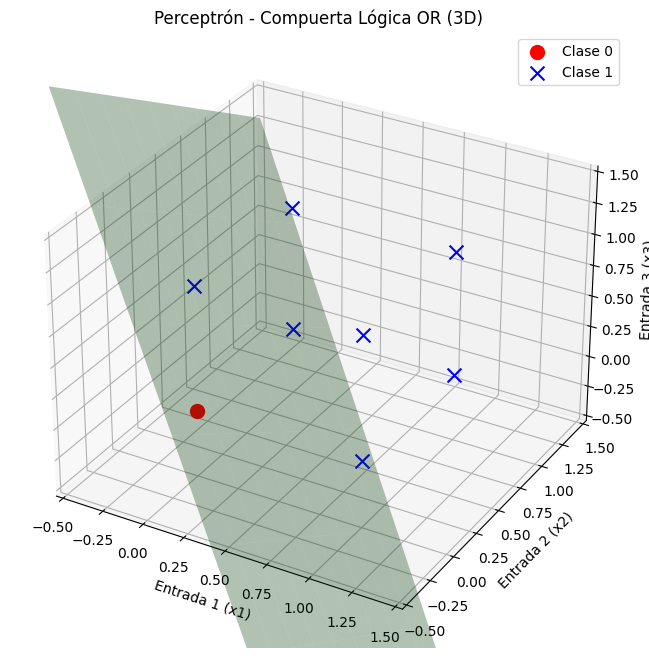

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos de datos para neurona 2
for i, xi in enumerate(X):
    if y1[i] == 0:
        ax.scatter(xi[0], xi[1], xi[2], color='red', marker='o', s=100, label='Clase 0' if i == 0 else "")
    else:
        ax.scatter(xi[0], xi[1], xi[2], color='blue', marker='x', s=100, label='Clase 1' if i == 1 else "")

# Definir el plano de decisión para OR
# w1*x1 + w2*x2 + w3*x3 + w0 = 0
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 10), np.linspace(-0.5, 1.5, 10))
zz = -(weights2[1] * xx + weights2[2] * yy + weights2[0]) / weights2[3]

# Graficar el plano de decisión
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

# Configuraciones de la gráfica
ax.set_xlabel('Entrada 1 (x1)')
ax.set_ylabel('Entrada 2 (x2)')
ax.set_zlabel('Entrada 3 (x3)')
ax.legend()
ax.set_title('Perceptrón - Compuerta Lógica OR (3D)')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_zlim(-0.5, 1.5)

plt.show()
